### Hare Krishna
today we are reproducing the hoppfield netwwork and well making this work or trying to make this work - started 24 Jul lol:))

In [230]:
class Network:

    @staticmethod
    def connection_strength(self):#this is all fine 
        rows , cols = self.shape
        result = []
        for i in range(cols):
            row = []
            for j in range(cols):
                val = 0

                if i == j :
                    row.append(0)
                else:
                    for k in range(rows):
                        val += self.binary[k][i]*self.binary[k][j]
                    
                    row.append(val)
            result.append(row)
        return result 

    

    #check this 
    def signal(self ,  noisy_pattern):###there is a serious bug here - there was absolutely no bug here- just that the data was shit 
        X = Network.bipolar(noisy_pattern)
        U = 0
        rows , cols  = self.shape 
        if len(X[0]) == cols :
            x = X[0]#this is entrering the updating loop - but smh not doing really well
            before = self.energy(x)
            for i in range(len(x)):
                val = 0 
                for j in range(cols):
                    val += self.connections[i][j] * x[j]
                if val > U :
                    x[i] = 1
                elif val < U:
                    x[i] = -1 
                else: 
                    pass
            after = self.energy(x)
            print(f"{before=} , {after=}")

            energy = self.energy(x)

            return x , energy

    def energy(self, x):
        out = 0 
        cols = len(x)

        for i in range(cols):
            for j in range(cols):
                out+=self.connections[i][j] * x[i]*x[j]

        e = -0.5*out 
        return e
        
            


    
    #here we might implement the multi sweep algorithm - in this type of algorithm what we would do is that 0 we would calculate the energy of many sweeps
    def recall(self , x  , max_sweeps):
        energies= []
        for i in range(max_sweeps):
            result = self.signal(x)
            x , energy= result 
            energies.append(energy)
            print(f"{energy=} , {x=} ,{i=}")

            if i>=1 and energies[i] == energies[i-1]:
                break

        return x , energy

        
        
        

    
    @staticmethod
    def check_shape(X):
        is_2d = isinstance(X ,list) and all(isinstance(row , list) for row in X)

        if is_2d :
            X = X 
        elif isinstance(X , list):
            X =[X]
        else:
            X = [[X]]
            
        
        dims = []
        row = len(X)
        col = len(X[0]) if isinstance(X[0] , list) else 1 
        dims.append(row)
        dims.append(col)
        
        return dims

    @staticmethod
    def bipolar(X):#in this there was a bug due to the 2v -1 = the 0/1 - were being coneverted into -1 , 1 but then the -1 was then into -3 and so on this was not good
        is_2d = isinstance(X ,list) and all(isinstance(row , list) for row in X)

        if is_2d :
            X = X 
        elif isinstance(X , list):
            X =[X]
        else:
            X = [[X]]
        row , col = Network.check_shape(X) 
        result = []
        for i in range(row):
            row = []
            for j in range(col):
                val = (X[i][j])

                if val == 1:
                    row.append(1)
                elif val == 0 :
                    row.append(-1)
                elif val == -1 :
                    row.append(-1)
                else:
                    raise ValueError("wtf")
            result.append(row)

        return result
                
        
    def __init__(self , data):
        self.data = data#this is the pattern stored or the data stored
        self.shape = Network.check_shape(self.data)
        self.binary = Network.bipolar(self.data)#so this converts the 0, 1 - > -1 , 1
        self.connections = Network.connection_strength(self)

    def __repr__(self):
        return f"patterns={self.patterns}"


In [231]:
patterns = [
    [ 1,-1,-1,-1, 1, 1, 1,-1, 1, 1, 1,-1],

    [-1, 1, 1,-1, 1, 1,-1, 1, 1, 1,-1, 1],

    [ 1, 1,-1,-1,-1, 1,-1,-1, 1, 1,-1, 1]
]

a = Network(patterns)#these are the number of patterns 
x =[-1, 1, 1, 1, 1,-1,-1,-1,-1, 1,-1, 1]

print(a.recall(x , 10))

before=-8.0 , after=-58.0
energy=-58.0 , x=[-1, 1, 1, -1, -1, 1, -1, 1, 1, 1, -1, 1] ,i=0
before=-58.0 , after=-64.0
energy=-64.0 , x=[-1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1] ,i=1
before=-64.0 , after=-64.0
energy=-64.0 , x=[-1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1] ,i=2
([-1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1], -64.0)


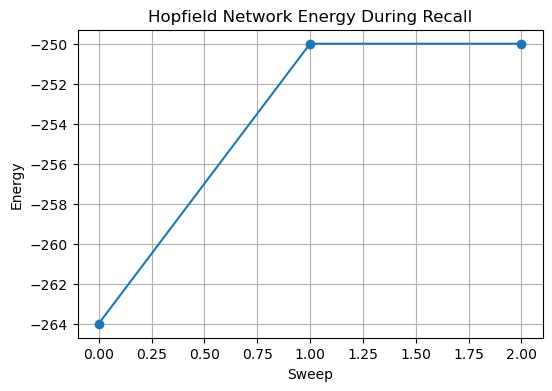

In [208]:
import matplotlib.pyplot as plt

energies = [-264, -250, -250]

plt.figure(figsize=(6,4))
plt.plot(range(len(energies)), energies, marker='o')
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title("Hopfield Network Energy During Recall")
plt.grid(True)

plt.show()